## **Churn Prediction**

- Churn Prediction means identifying which customer will likely stop using the company's product or service

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
data = "https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv"

In [3]:
# !wget $data

## **Data Preparation**

In [4]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


### **Data cleansing**

In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Look at TotalCharges it is object type, investigate, it should be float since we are talking about numerical value

In [9]:
(df.dtypes == "object").index

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [10]:
# convert all the columns to lowercase, change spaces to _

df.columns = df.columns.str.lower().str.replace(' ','_')

# categorical columns, when the dtype is object
categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)

# converting all the value to lowercase, change space to _
for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')


In [11]:
df.head().T

,0,1,2,3,4
customerid,7590-vhveg,5575-gnvde,3668-qpybk,7795-cfocw,9237-hqitu
gender,female,male,male,male,female
seniorcitizen,0,0,0,0,0
partner,yes,no,no,no,no
dependents,no,no,no,no,no
tenure,1,34,2,45,2
phoneservice,no,yes,yes,no,yes
multiplelines,no_phone_service,no,no,no_phone_service,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic
onlinesecurity,no,yes,yes,yes,no


We can also replace '-' to '_'

totalcharges has value like '29.85', '1889.5'

In [12]:
# pd.to_numeric(df.totalcharges)

**Error**: Unable to parse string "_" at position 488
- This means it has spaces (remember, we converted space to underscore )

In [13]:
# Ignore this error first using coerce
tc = pd.to_numeric(df.totalcharges, errors='coerce')
tc.isnull().sum()

np.int64(11)

In [14]:
# let's explore this 11 values: <df><listofcolumn>
ngi = df[tc.isnull()][['customerid', 'totalcharges']]
ngi

,customerid,totalcharges
488,4472-lvygi,_
753,3115-czmzd,_
936,5709-lvoeq,_
1082,4367-nuyao,_
1340,1371-dwpaz,_
3331,7644-omvmy,_
3826,3213-vvolg,_
4380,2520-sgtta,_
5218,2923-arzlg,_
6670,4075-wkniu,_


In [15]:
# Replace these values to 0 using fillna because we already know we can access tjem via isnull 


df.totalcharges = pd.to_numeric(df.totalcharges, errors="coerce")
df.totalcharges = df.totalcharges.fillna(0)


Checking the target variable

In [16]:
df.churn.head()

0     no
1     no
2    yes
3     no
4    yes
Name: churn, dtype: object

In [17]:
df['churn'] = (df['churn'] == 'yes').astype(int)

## **Setting up the Validation Framework**

Perform the train/validation/test split with Scikit-Learn

In [18]:
from sklearn.model_selection import train_test_split

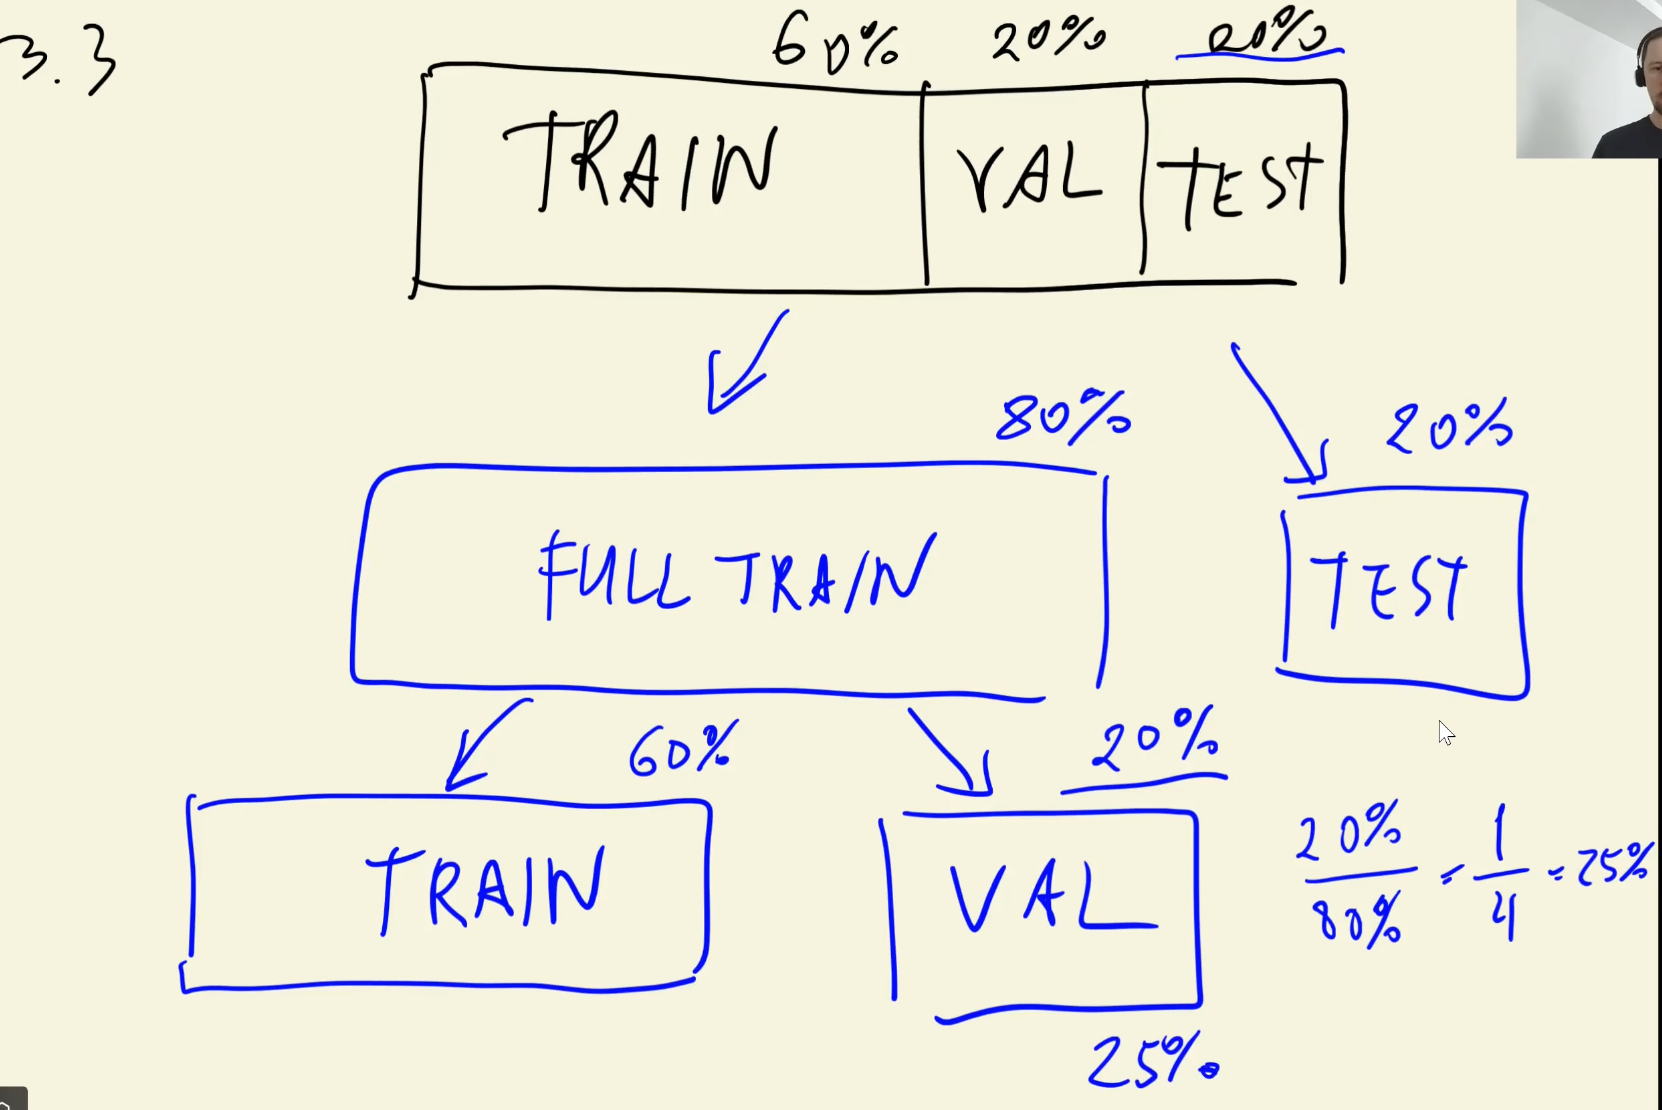

In [19]:
# know more about this fuction
train_test_split?

Signature:
train_test_split(
    *arrays,
    test_size=None,
    train_size=None,
    random_state=None,
    shuffle=True,
    stratify=None,
)
Docstring:
Split arrays or matrices into random train and test subsets.

Quick utility that wraps input validation,
``next(ShuffleSplit().split(X, y))``, and application to input data
into a single call for splitting (and optionally subsampling) data into a
one-liner.

Read more in the :ref:`User Guide <cross_validation>`.

Parameters
----------
*arrays : sequence of indexables with same length / shape[0]
    Allowed inputs are lists, numpy arrays, scipy-sparse
    matrices or pandas dataframes.

test_size : float or int, default=None
    If float, should be between 0.0 and 1.0 and represent the proportion
    of the dataset to include in the test split. If int, represents the
    absolute number of test samples. If None, the value is set to the
    complement of the train size. If ``train_size`` is also None, it will
    be set to 0.25.

trai

Split the data (100%) to full train (80%) and test (20%) 

In [20]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1 )

In [21]:
len(df_full_train), len(df_test)

(5634, 1409)

Split the full train(80%) to train (60%) and validation (20%).

20/80 = 1/4 = 0.25

In [22]:
df_train, df_val = train_test_split(df_full_train, test_size=0.25 , random_state=1 )

In [23]:
len(df_train), len(df_val)

(4225, 1409)

In [24]:
#resetting the index for visuality purposes
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_train.head(2)

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,8015-ihcgw,female,0,yes,yes,72,yes,yes,fiber_optic,yes,...,yes,yes,yes,yes,two_year,yes,electronic_check,115.50,8425.15,0
1,1960-uycnn,male,0,no,no,10,yes,yes,fiber_optic,no,...,yes,no,no,yes,month-to-month,yes,electronic_check,95.25,1021.55,0


In [25]:
df_train.churn.values

array([0, 0, 1, ..., 1, 0, 1], shape=(4225,))

In [26]:
# assigning the target variable into a python variable

y_train = df_train.churn.values # use .value function to convert it to an array 
y_test = df_test.churn.values 
y_val = df_val.churn.values 

In [27]:
# delete the target variable from the df

del df_train['churn']
del df_test['churn']
del df_val['churn']

## **EDA**
- for the full dataset

In [28]:
df_full_train.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [29]:
df_full_train.churn.value_counts(normalize=True) # use normalize to check the percentage

churn
0    0.730032
1    0.269968
Name: proportion, dtype: float64

The current churn rate is 27%

In [30]:
# You can actually find the churn rate using mean
global_churn_rate = round(df_full_train.churn.mean(),2)
global_churn_rate

np.float64(0.27)

**Checking the numerical variables of the data** 

In [31]:
df_full_train.dtypes

customerid           object
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges        float64
churn                 int64
dtype: object

tenure, monthlycharges, totalcharges

In [32]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

In [33]:
categorical = ['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
        'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'churn']

In [34]:
df_full_train[categorical].nunique()

customerid          5634
gender                 2
seniorcitizen          2
partner                2
dependents             2
phoneservice           2
multiplelines          3
internetservice        3
onlinesecurity         3
onlinebackup           3
deviceprotection       3
techsupport            3
streamingtv            3
streamingmovies        3
contract               3
paperlessbilling       2
paymentmethod          4
churn                  2
dtype: int64

## **Feature Importance: Churn rate**

In [35]:
df_full_train.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
1814,5442-pptjy,male,0,yes,yes,12,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.70,258.35,0
5946,6261-rcvns,female,0,no,no,42,yes,no,dsl,yes,...,yes,yes,no,yes,one_year,no,credit_card_(automatic),73.90,3160.55,1
3881,2176-osjuv,male,0,yes,no,71,yes,yes,dsl,yes,...,no,yes,no,no,two_year,no,bank_transfer_(automatic),65.15,4681.75,0
2389,6161-erdgd,male,0,yes,yes,71,yes,yes,dsl,yes,...,yes,yes,yes,yes,one_year,no,electronic_check,85.45,6300.85,0
3676,2364-ufrom,male,0,no,no,30,yes,no,dsl,yes,...,no,yes,yes,no,one_year,no,electronic_check,70.40,2044.75,0


Checking the churn rate in terms of sex

In [36]:
churn_female = df_full_train[df_full_train['gender'] == 'female'].churn.mean()
churn_male = df_full_train[df_full_train['gender'] == 'male'].churn.mean()

global_churn_rate, churn_female, churn_male


(np.float64(0.27),
 np.float64(0.27682403433476394),
 np.float64(0.2632135306553911))

Checking the churn rate in terms if they have a partner

In [37]:
churn_partner = df_full_train[df_full_train['partner'] == 'yes'].churn.mean()
churn_no_partner = df_full_train[df_full_train['partner'] == 'no'].churn.mean()

churn_partner, churn_no_partner, global_churn_rate-churn_partner, global_churn_rate-churn_no_partner


(np.float64(0.20503330866025166),
 np.float64(0.3298090040927694),
 np.float64(0.06496669133974836),
 np.float64(-0.0598090040927694))

We can see that for those who have a partner, they have a drop of around 6 points for churn rate. That case is different for those who have no partner

### **Note**:
If the difference of the churn rate between the global and group is greater than 0, then it is less likely to churn.

But if it is less than 0, then it is more likely to churn

#### Risk Ratio

>1 more likely to churn
<1 less likely to churn

In [38]:
churn_no_partner / global_churn_rate

np.float64(1.22151482997322)

In [39]:
churn_male / global_churn_rate

np.float64(0.9748649283533003)

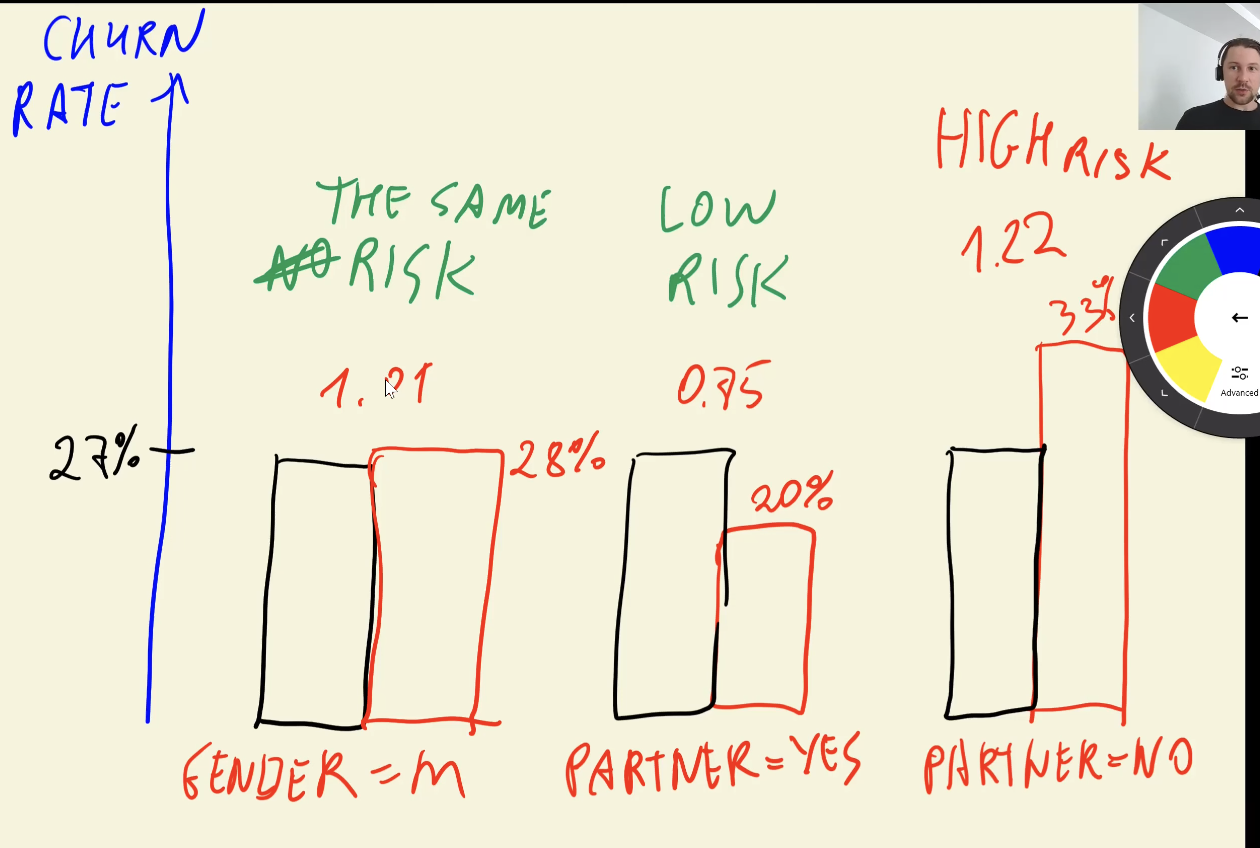

Better way to do this

SELECT gender,
    AVG(churn),
    AVG(churn) - global_churn AS diff,
    AVG(churn) / global_churn AS risk
FROM
    data
GROUP BY 
    gender

In [40]:
df_full_train.groupby('gender').churn.mean()

gender
female    0.276824
male      0.263214
Name: churn, dtype: float64

In [41]:
# This script does the AVG(churn) and added count
df_group = df_full_train.groupby('gender').churn.agg(['mean', 'count'])
df_group

,mean,count
gender,,
female,0.276824,2796
male,0.263214,2838


In [42]:
df_group['diff'] = df_group['mean'] - global_churn_rate
df_group['risk'] = df_group['mean'] / global_churn_rate
df_group

,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006824,1.025274
male,0.263214,2838,-0.006786,0.974865


## **Feature Importance**

Mutual Information = is a concept from information theory, it tells us how much we can learn about one variable once we know the value of another. (Parang doblekara? haha )

Use risk ratio to measure which variables are important. >1 will most likely to churn, <1 will less likely to churcn

In [44]:
# Doing it all to the categorical variables.
from IPython.display import display

for c in categorical:
    print(c)
    df_group = df_full_train.groupby(c).churn.agg(['mean', 'count'])
    df_group['diff'] = df_group['mean'] - global_churn_rate
    df_group['risk'] = df_group['mean'] / global_churn_rate
    display(df_group)
    print()
    print()

customerid


,mean,count,diff,risk
customerid,,,,
0002-orfbo,0.0,1,-0.27,0.000000
0004-tlhlj,1.0,1,0.73,3.703704
0011-igkff,1.0,1,0.73,3.703704
0013-exchz,1.0,1,0.73,3.703704
0013-mhzwf,0.0,1,-0.27,0.000000
...,...,...,...,...
9987-lutyd,0.0,1,-0.27,0.000000
9992-rramn,1.0,1,0.73,3.703704
9992-ujoel,0.0,1,-0.27,0.000000




gender


,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006824,1.025274
male,0.263214,2838,-0.006786,0.974865




seniorcitizen


...

,mean,count,diff,risk
paperlessbilling,,,,
no,0.172071,2313,-0.097929,0.637300
yes,0.338151,3321,0.068151,1.252412




paymentmethod


,mean,count,diff,risk
paymentmethod,,,,
bank_transfer_(automatic),0.168171,1219,-0.101829,0.622854
credit_card_(automatic),0.164339,1217,-0.105661,0.608661
electronic_check,0.455890,1893,0.185890,1.688482
mailed_check,0.193870,1305,-0.076130,0.718036




churn


,mean,count,diff,risk
churn,,,,
0,0.0,4113,-0.27,0.000000
1,1.0,1521,0.73,3.703704


In [45]:
# importing the function mutual_info_score() to perform mutual information
from sklearn.metrics import mutual_info_score

In [ ]:
mutual_info_score(df_full_train.churn, df_full_train.contract)

np.float64(0.0983203874041556)

In [47]:
mutual_info_score(df_full_train.churn, df_full_train.gender)

np.float64(0.0001174846211139946)

In [48]:
mutual_info_score(df_full_train.churn, df_full_train.partner)

np.float64(0.009967689095399745)

In [49]:
mutual_info_score(df_full_train.churn, df_full_train.techsupport)

np.float64(0.06103245991777444)

In [58]:
for c in categorical:
    
    score = (mutual_info_score(df_full_train[c], df_full_train['churn']))
    if score > 0.05:
        print(c)
        print(score)
        print()

customerid
0.5832270604600807

internetservice
0.055867945893496467

onlinesecurity
0.06308524972985574

techsupport
0.06103245991777444

contract
0.0983203874041556

churn
0.5832270604600812



Different way to apply the for loops: using . apply() function

to use the apply() function you need to have a def function first

In [63]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_full_train.churn)

In [67]:
mut_score = df_full_train[categorical].apply(mutual_info_churn_score)
mut_score.sort_values(ascending=False)

churn               0.583227
customerid          0.583227
contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

## **Feature Importance**: Using Correlation

Pearson vs Spearman

low, moderate and strong correlation

rarely, sometimes, often /  almost always

In [68]:
df_full_train[numerical]

,tenure,monthlycharges,totalcharges
1814,12,19.70,258.35
5946,42,73.90,3160.55
3881,71,65.15,4681.75
2389,71,85.45,6300.85
3676,30,70.40,2044.75
...,...,...,...
905,9,100.50,918.60
5192,60,19.95,1189.90
3980,28,105.70,2979.50
235,2,54.40,114.10


In [69]:
df_full_train[numerical].corrwith(df_full_train['churn'])

tenure           -0.351885
monthlycharges    0.196805
totalcharges     -0.196353
dtype: float64

Based on the correlation coefficient, the more tenure a person is the less likely they will churn. On the other hand, the higher the monthly charges the more likely they will churn

In [82]:
# Taking a look at them

print(df_full_train[df_full_train['tenure'] <= 2].churn.mean()) # less than  2 months in company

print(df_full_train[(df_full_train['tenure'] > 2) & (df_full_train['tenure'] <= 12)].churn.mean())  # 2-12 months in the company

print(df_full_train[df_full_train['tenure'] > 24].churn.mean()) # > 24 months in the company

0.5953420669577875
0.3994413407821229
0.1430904933028422


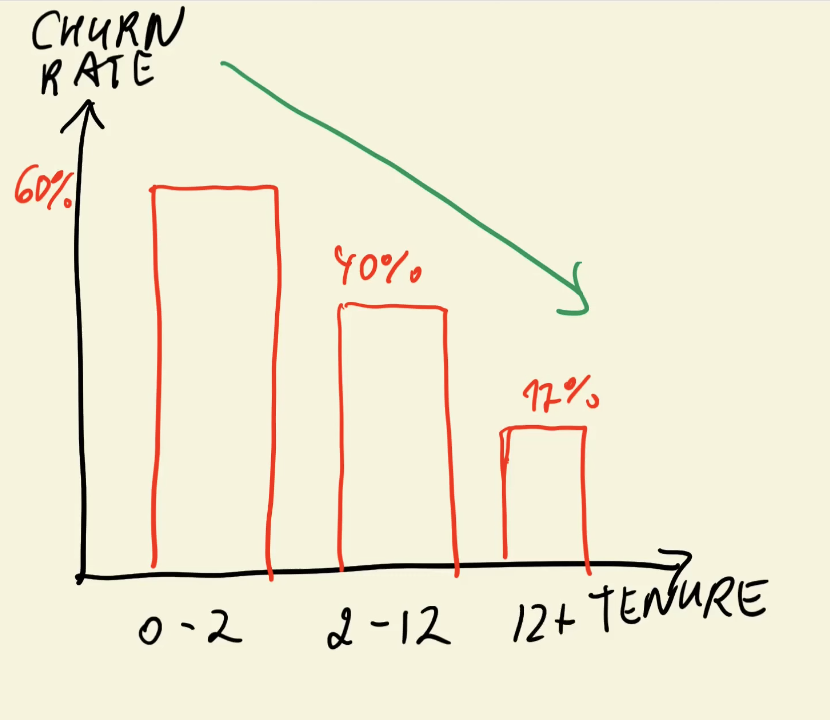